# Being of Light Analysis: Profiling the Phenomenon

**Purpose:** Empirically profile the Being of Light through measurable characteristics — presence patterns, personality, communication, identification, and transformative effects.

**Dataset:** 6,751 NDEs (NDERF + IANDS; 2 exact duplicate narratives removed)

**Schema:** 2026-01-06 (`models/questionnaire.py`) · **Original analysis:** January 6, 2026 · **Audited and corrected:** October 5, 2026

---

## Research Framework

1. **Presence** — How often does the Being appear? Is this consistent across demographics?
2. **Personality** — What is the character of the judgment it delivers?
3. **Communication** — How does it communicate? What guidance does it provide?
4. **Identification** — How do experiencers name it? Does vocabulary vary while properties stay constant?
5. **Transformation** — What effects follow the encounter?

**Methodological note:** we measure the *pattern consistency* of the phenomenon. Results are reported at three levels — statistically supported, reasonable interpretation, speculative — per the project's research-integrity rules.

## Audit corrections (2026-10-05)

The previous version of this notebook contained errors that changed headline results. All are fixed below; see `docs/STATISTICAL_AUDIT_2026-10.md` for the full audit.

| # | Problem in previous version | Effect | Fix |
|---|---|---|---|
| 1 | Death-fear scale mapped `extreme/high/low`, values that do not exist; `significant` and `severe` were silently dropped | n = 33 instead of 117; "0.0% increased fear" was an artifact | Correct 5-level scale (`none`…`severe`) |
| 2 | Spirituality scale lacked `central` | n = 190 instead of 305 | Correct 5-level scale |
| 3 | Emotional-tone categories `peaceful/loving/joyful/distressing` do not exist in the schema | "Peaceful emotional tone: 0.0%" | Schema values `love`, `shame_or_regret`, `mixed`, … |
| 4 | "No external judgment" counted `not_mentioned` as "no judgment"; intensity percentages used all reviews as denominator | 54.7% "no external judgment"; 32.2% "loving among those judged" | Denominators restricted to classifiable/rated cases; CIs added |
| 5 | Communication percentages were shares of *mentions*, not of experiencers | 34.8% "telepathic" | Per-experiencer rates |
| 6 | Cell 23 contained code that depended on a later cell (out-of-order execution) | Notebook did not run top-to-bottom | Removed; notebook now executes cleanly |
| 7 | χ² = 365.14 (religion × identification) used a table where 69% of cells had expected count < 5; 82% of the statistic came from 2 Buddhists naming the Buddha | Inflated test statistic | Permutation test + collapsed table with valid expected counts |
| 8 | "Unknown vs identified" and expectation-correction cells used non-existent labels (`'None/Agnostic/Atheist'`, `'Christian'`) and diluted denominators | Empty or meaningless output | Proper comparisons with tests |
| 9 | ML test trained on 183 cases with arbitrary age imputation (test n = 37) | "Below baseline" was overfitting | Religion-only model, cross-validated log-loss |
| 10 | Light-Being vs other-being comparisons ignored narrative length (Light-Being accounts are ~45% longer) | Possible confounding | Logistic regressions adjusted for log word count |

## Setup

In [1]:
import sys, json, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, fisher_exact, mannwhitneyu, wilcoxon
from statsmodels.stats.multitest import multipletests

NDE_ROOT = Path.cwd().parent
sys.path.insert(0, str(NDE_ROOT / "scripts"))
import nde_dataset as nd  # verified loader: schema-checked fields, dedup, narrative word counts

OUTPUT_DIR = NDE_ROOT / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 8)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

df = nd.load_frame()          # one row per NDE; exact duplicate narratives removed
N = len(df)
print(f"Loaded {N:,} records (after removing exact duplicate narratives)")
print(df["dataset"].value_counts().to_string())

Loaded 6,751 records (after removing exact duplicate narratives)
dataset
nderf    5659
iands    1092


## Defining the Light-Being subset — and what it contains

The subset analysed in this notebook is defined from `being_identifications`: any of `god`, `jesus`, `religious_figure_specified`, `buddha`, `unknown_presence`. This is **not** the same as the `light_encounter == "being_of_light"` field used in notebooks 05 and 06. The cross-tabulation below shows how the two operationalisations relate.

In [2]:
lb = df[df["has_light_being"]].copy()
other_only = df[df["has_other_being"] & ~df["has_light_being"]].copy()
no_beings = df[~df["has_light_being"] & ~df["has_other_being"]]

print(f"Light-Being identifications: {nd.fmt_pct(len(lb), N)}")
print(f"Other beings only:          {nd.fmt_pct(len(other_only), N)}")
print(f"No beings identified:        {nd.fmt_pct(len(no_beings), N)}")
print(f"Light Being + other beings: {int(lb['has_other_being'].sum()):,};  Light Being only: {int((~lb['has_other_being']).sum()):,}")

print("\nlight_encounter coding within the Light-Being subset:")
print(lb["light_encounter"].value_counts().to_frame("n").assign(pct=lambda t: (100 * t.n / len(lb)).round(1)).to_string())

print("\nOverall valence within the Light-Being subset:")
print(lb["overall_valence"].value_counts().to_string())

print("\nMedian narrative length (words): Light Being %.0f | other beings only %.0f | no beings %.0f"
      % (lb.word_count.median(), other_only.word_count.median(), no_beings.word_count.median()))

Light-Being identifications: 1881/6751 = 27.9% [95% CI 26.8–28.9]
Other beings only:          1898/6751 = 28.1% [95% CI 27.1–29.2]
No beings identified:        2972/6751 = 44.0% [95% CI 42.8–45.2]
Light Being + other beings: 771;  Light Being only: 1,110

light_encounter coding within the Light-Being subset:
                           n   pct
light_encounter                   
brilliant_light          671  35.7
being_of_light           599  31.8
no                       273  14.5
presence_without_visual  229  12.2
not_mentioned            109   5.8

Overall valence within the Light-Being subset:
overall_valence
mixed                  903
incredibly_pleasant    595
pleasant               274
not_mentioned           65
terrifying              21
neutral                 16
distressing              7

Median narrative length (words): Light Being 1028 | other beings only 710 | no beings 506


**Construct note.** Only about a third of the Light-Being subset was coded `light_encounter = being_of_light`, and roughly one in seven was coded as having **no light at all** (`no`). The subset is therefore best described as *"encounters identified as a divine figure or as an unidentified presence"*. A small number are distressing or terrifying. Results below describe this subset; they should not be read as properties of a visually luminous being specifically. Light-Being accounts are also substantially longer than other accounts, so between-group comparisons are reported both crude and adjusted for narrative length.

---
# PART I: The Presence of the Being

**Question:** How reliably does the Being appear, and does presence vary by religious background, gender, or age?

In [3]:
print("1. OVERALL PRESENCE RATE:", nd.fmt_pct(len(lb), N))

print("\n2. PRESENCE BY RELIGIOUS BACKGROUND")
rel_tab = (df.groupby("religious_background")["has_light_being"].agg(["size", "sum"])
           .rename(columns={"size": "N", "sum": "light_being"}))
rel_tab["presence_%"] = (100 * rel_tab.light_being / rel_tab.N).round(1)
rel_tab["95% CI"] = [f"{100*lo:.1f}–{100*hi:.1f}" for lo, hi in (nd.wilson_ci(k, n) for k, n in zip(rel_tab.light_being, rel_tab.N))]
print(rel_tab.sort_values("N", ascending=False).to_string())

groups = ["christian", "atheist_agnostic", "spiritual_not_religious", "other", "jewish", "muslim"]
sub = df[df["religious_background"].isin(groups)]
table = pd.crosstab(sub["religious_background"], sub["has_light_being"])
chi2, p, dof, _ = chi2_contingency(table)
print(f"\nχ² test (6 backgrounds with expected counts ≥ 5): χ² = {chi2:.2f}, df = {dof}, p = {p:.2g}, Cramér's V = {nd.cramers_v(table):.3f}")
print("   " + nd.expected_count_report(table))
print("   (Hindu n=15 and Buddhist n=14 are too small for this test and are reported descriptively.)")

mentioned = df["religious_background"] != "not_mentioned"
print(f"\nReligion mentioned: presence {100*df.loc[mentioned,'has_light_being'].mean():.1f}%, median words {df.loc[mentioned,'word_count'].median():.0f}")
print(f"Religion not mentioned: presence {100*df.loc[~mentioned,'has_light_being'].mean():.1f}%, median words {df.loc[~mentioned,'word_count'].median():.0f}")

1. OVERALL PRESENCE RATE: 1881/6751 = 27.9% [95% CI 26.8–28.9]

2. PRESENCE BY RELIGIOUS BACKGROUND
                            N  light_being  presence_%     95% CI
religious_background                                             
not_mentioned            5122         1291        25.2  24.0–26.4
christian                1282          509        39.7  37.1–42.4
other                     115           28        24.3  17.4–32.9
atheist_agnostic          100           24        24.0  16.7–33.2
muslim                     43            4         9.3   3.7–21.6
jewish                     38           11        28.9  17.0–44.8
spiritual_not_religious    22            6        27.3  13.2–48.2
hindu                      15            3        20.0   7.0–45.2
buddhist                   14            5        35.7  16.3–61.2

χ² test (6 backgrounds with expected counts ≥ 5): χ² = 35.25, df = 5, p = 1.3e-06, Cramér's V = 0.148
   min expected = 8.00; cells with expected < 5: 0%
   (Hindu n=15 and 

**Finding (statistically supported):** presence is **not** uniform across religious backgrounds (χ² test above, p < 0.001). Christians report the highest rate (~40%) and Muslims the lowest (~9%, n = 43). Religion is only recorded for ~24% of accounts, and those accounts are about three times longer, so absolute rates for named religions are not representative of the whole archive.

In [4]:
print("3. PRESENCE BY GENDER")
g = df[df["gender"].isin(["male", "female"])]
gt = pd.crosstab(g["gender"], g["has_light_being"])
chi2, p, dof, _ = chi2_contingency(gt)
for sex in ["male", "female"]:
    print(f"  {sex}: {nd.fmt_pct(int(gt.loc[sex, True]), int(gt.loc[sex].sum()))}")
print(f"  χ² = {chi2:.2f}, df = {dof}, p = {p:.3f}")
print(f"  gender not mentioned: {nd.fmt_pct(int(df.loc[df.gender=='not_mentioned','has_light_being'].sum()), int((df.gender=='not_mentioned').sum()))}")

print("\n4. PRESENCE BY AGE AT NDE (age reported for", int(df['age_at_nde'].notna().sum()), "records)")
a = df[df["age_at_nde"].notna()].copy()
a["age_group"] = pd.cut(a["age_at_nde"], bins=[-1, 17, 35, 55, 200], labels=["0–17", "18–35", "36–55", "56+"])
at = pd.crosstab(a["age_group"], a["has_light_being"])
for grp in at.index:
    print(f"  {grp}: {nd.fmt_pct(int(at.loc[grp, True]), int(at.loc[grp].sum()))}")
chi2, p, dof, _ = chi2_contingency(at)
print(f"  χ² = {chi2:.2f}, df = {dof}, p = {p:.3f}")
print(f"  Median age among records with age: {a['age_at_nde'].median():.0f} (age is mostly reported for childhood NDEs)")

3. PRESENCE BY GENDER
  male: 489/1559 = 31.4% [95% CI 29.1–33.7]
  female: 838/2710 = 30.9% [95% CI 29.2–32.7]
  χ² = 0.07, df = 1, p = 0.789
  gender not mentioned: 553/2481 = 22.3% [95% CI 20.7–24.0]

4. PRESENCE BY AGE AT NDE (age reported for 1558 records)
  0–17: 285/970 = 29.4% [95% CI 26.6–32.3]
  18–35: 131/400 = 32.8% [95% CI 28.3–37.5]
  36–55: 51/137 = 37.2% [95% CI 29.6–45.6]
  56+: 16/51 = 31.4% [95% CI 20.3–45.0]
  χ² = 4.25, df = 3, p = 0.236
  Median age among records with age: 15 (age is mostly reported for childhood NDEs)


**Finding:** presence does not differ by gender or by age group (both p > 0.2). Age is reported for only ~23% of records and is skewed toward childhood experiences (median 15), so the age result applies to that subset.

In [5]:
print("5. MONOTHEISTIC vs HINDU/BUDDHIST vs NON-RELIGIOUS BACKGROUNDS")
traditions = {
    "Monotheistic (Christian/Muslim/Jewish)": ["christian", "muslim", "jewish"],
    "Hindu/Buddhist": ["hindu", "buddhist"],
    "Non-religious (atheist/agnostic, SBNR)": ["atheist_agnostic", "spiritual_not_religious"],
}
for label, members in traditions.items():
    s = df[df["religious_background"].isin(members)]
    print(f"  {label}: {nd.fmt_pct(int(s['has_light_being'].sum()), len(s))}")

hb = df[df["religious_background"].isin(["hindu", "buddhist"]) & df["has_light_being"]]
print(f"\nAll {len(hb)} Hindu/Buddhist Light-Being cases (the entire evidential basis for any 'polytheist' claim):")
print(hb[["religious_background", "being_identifications", "religious_figure_detail", "other_being_detail"]].to_string())

multi = lb["being_identifications"].apply(lambda ids: len(set(ids) & set(nd.RELIGIOUS_FIGURE_IDS)))
print(f"\nLight-Being cases naming two or more distinct religious figures: {int((multi >= 2).sum())} of {len(lb)}"
      f" (God + Jesus together: {int(lb['being_identifications'].apply(lambda x: 'god' in x and 'jesus' in x).sum())})")

5. MONOTHEISTIC vs HINDU/BUDDHIST vs NON-RELIGIOUS BACKGROUNDS


  Monotheistic (Christian/Muslim/Jewish): 524/1363 = 38.4% [95% CI 35.9–41.1]
  Hindu/Buddhist: 8/29 = 27.6% [95% CI 14.7–45.7]
  Non-religious (atheist/agnostic, SBNR): 30/122 = 24.6% [95% CI 17.8–32.9]

All 8 Hindu/Buddhist Light-Being cases (the entire evidential basis for any 'polytheist' claim):
     religious_background                         being_identifications                                                                                       religious_figure_detail                                                                                                                                                                              other_being_detail
656                 hindu                     [other, unknown_presence]                                                                                                           NaN  An 'unearthly man' in the sky who said 'You can do it'; later an 'unearthly wise man' who led him; later 'four intelligent beings' looking at

**Finding on "singularity" — not testable with this schema.** The schema records *which kinds* of being were identified, not *how many* beings of light were present, so it cannot show that the Being is experienced as one entity. The Hindu/Buddhist evidence consists of 8 cases; at least two of them name more than one divine figure (e.g. Buddha + Guanyin + angels; God + Jesus) and one describes "four intelligent beings". The previous claim that "even polytheists encounter a SINGULAR transcendent entity" is therefore **not supported** by this dataset; the question is **underdetermined**, not confirmed.

In [6]:
print("6. GUIDANCE: LIGHT-BEING vs OTHER-BEINGS-ONLY ENCOUNTERS")
cmp = pd.concat([lb.assign(light_being=1), other_only.assign(light_being=0)])
cmp["significant_guidance"] = ((cmp["guidance_received"] == "yes") & (cmp["guidance_types"].apply(len) > 0)).astype(int)
gt = pd.crosstab(cmp["light_being"], cmp["significant_guidance"])
chi2, p, dof, _ = chi2_contingency(gt)
r1, r0 = cmp.groupby("light_being")["significant_guidance"].mean()[[1, 0]]
adj = nd.adjusted_odds_ratio(cmp, "significant_guidance", "light_being")
print(f"  Light Being:      {nd.fmt_pct(int(gt.loc[1,1]), int(gt.loc[1].sum()))}")
print(f"  Other beings only: {nd.fmt_pct(int(gt.loc[0,1]), int(gt.loc[0].sum()))}")
print(f"  χ² = {chi2:.2f}, df = {dof}, p = {p:.2g};  rate ratio = {r1/r0:.2f}")
print(f"  OR crude = {adj['crude_or']:.2f}; adjusted for log word count = {adj['adj_or']:.2f} "
      f"(95% CI {adj['adj_ci'][0]:.2f}–{adj['adj_ci'][1]:.2f}), p = {adj['adj_p']:.2g}")
print("  NOTE: guidance is coded per NDE, not per being; in 771 Light-Being cases other beings were also present.")

6. GUIDANCE: LIGHT-BEING vs OTHER-BEINGS-ONLY ENCOUNTERS


  Light Being:      1537/1881 = 81.7% [95% CI 79.9–83.4]
  Other beings only: 1422/1898 = 74.9% [95% CI 72.9–76.8]
  χ² = 25.24, df = 1, p = 5.1e-07;  rate ratio = 1.09
  OR crude = 1.50; adjusted for log word count = 1.34 (95% CI 1.14–1.57), p = 0.00039
  NOTE: guidance is coded per NDE, not per being; in 771 Light-Being cases other beings were also present.


**Finding (statistically supported, modest):** guidance is more frequent in Light-Being encounters (81.7% vs 74.9%), and the difference survives adjustment for narrative length. The ratio is **1.09×**, not "nearly 2×" as previously stated elsewhere in the project; the ~2× difference applies to *teaching* specifically (Part III).

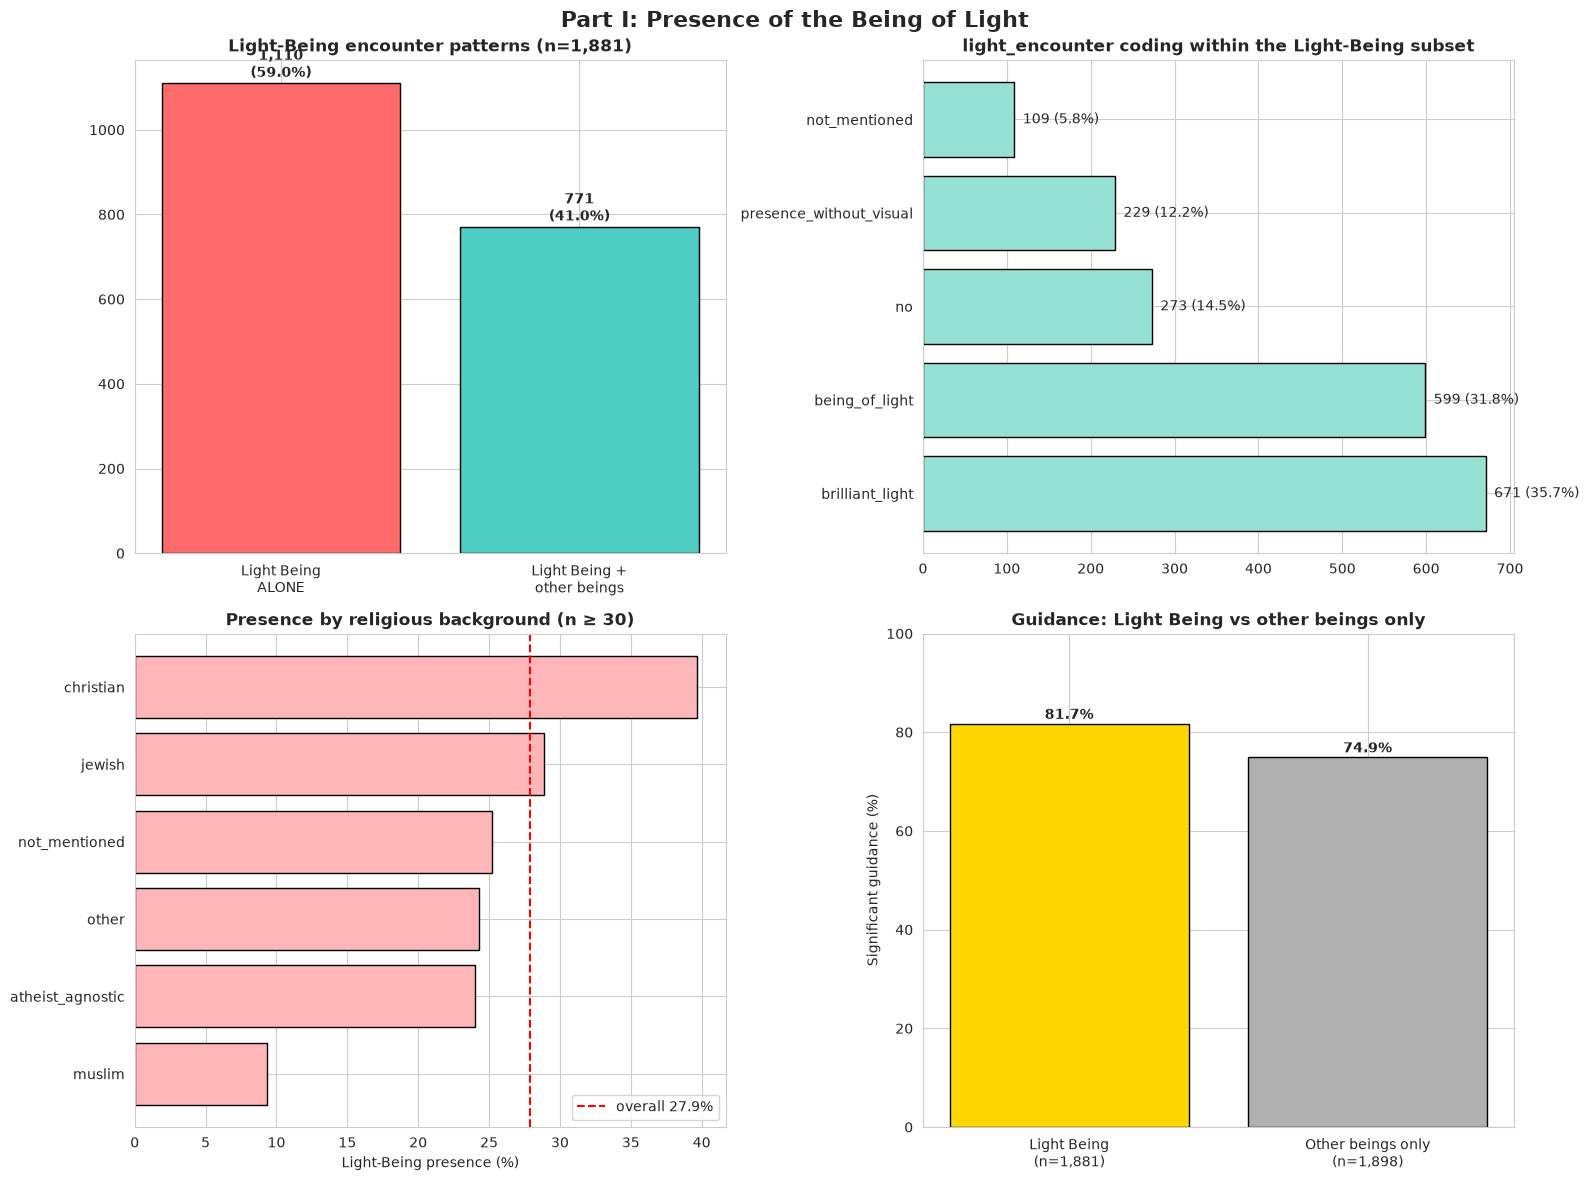

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
ax = axes[0, 0]
counts = [int((~lb["has_other_being"]).sum()), int(lb["has_other_being"].sum())]
ax.bar(["Light Being\nALONE", "Light Being +\nother beings"], counts, color=["#FF6B6B", "#4ECDC4"], edgecolor="black")
for i, c in enumerate(counts):
    ax.text(i, c + 15, f"{c:,}\n({100*c/len(lb):.1f}%)", ha="center", fontweight="bold")
ax.set_title(f"Light-Being encounter patterns (n={len(lb):,})", fontweight="bold")

ax = axes[0, 1]
lb_light = lb["light_encounter"].value_counts()
ax.barh(lb_light.index, lb_light.values, color="#95E1D3", edgecolor="black")
ax.set_title("light_encounter coding within the Light-Being subset", fontweight="bold")
for i, v in enumerate(lb_light.values):
    ax.text(v + 10, i, f"{v} ({100*v/len(lb):.1f}%)", va="center")

ax = axes[1, 0]
show = rel_tab[rel_tab.N >= 30].sort_values("presence_%")
ax.barh(show.index, show["presence_%"], color="#FFB6B9", edgecolor="black")
ax.axvline(100 * len(lb) / N, color="red", ls="--", label=f"overall {100*len(lb)/N:.1f}%")
ax.set_xlabel("Light-Being presence (%)"); ax.legend()
ax.set_title("Presence by religious background (n ≥ 30)", fontweight="bold")

ax = axes[1, 1]
ax.bar([f"Light Being\n(n={len(lb):,})", f"Other beings only\n(n={len(other_only):,})"], [100*r1, 100*r0],
       color=["#FFD700", "#B0B0B0"], edgecolor="black")
for i, v in enumerate([100*r1, 100*r0]):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center", fontweight="bold")
ax.set_ylim(0, 100); ax.set_ylabel("Significant guidance (%)")
ax.set_title("Guidance: Light Being vs other beings only", fontweight="bold")
plt.suptitle("Part I: Presence of the Being of Light", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_part1_being_of_light.png", dpi=150, bbox_inches="tight")
plt.show()

---
# PART II: The Personality of the Being

**Question:** What is the character of the judgment delivered during life reviews?

Three distinct schema fields are used and must not be conflated:
- `judgment_source` — *who* evaluated (self, Being of Light, guide, relative, none);
- `judgment_intensity` — the *character* of the evaluation (loving_gentle … harsh_condemning);
- `life_review_emotional_tone` — how the *experiencer felt*.

Denominators: source percentages exclude `not_mentioned`; intensity percentages use only rated cases (`not_applicable`/`not_specified` excluded).

In [8]:
review = lb[lb["life_review"]].copy()
print(f"Life reviews among Light-Being encounters: {nd.fmt_pct(len(review), len(lb))}")

def judgment_profile(frame, label):
    print(f"\n=== {label} (n = {len(frame)}) ===")
    src = frame["judgment_source"].value_counts()
    classifiable = frame[frame["judgment_source"] != "not_mentioned"]
    ext = classifiable["judgment_source"].isin(["being_of_light", "guide_or_entity", "deceased_relative"]).sum()
    print("judgment_source:", src.to_dict())
    print(f"  External evaluator (Being/guide/relative) among classifiable: {nd.fmt_pct(int(ext), len(classifiable))}")
    print(f"  No judgment or self-judgment among classifiable:               {nd.fmt_pct(len(classifiable) - int(ext), len(classifiable))}")
    rated = frame[frame["judgment_intensity"].isin(["loving_gentle", "neutral", "uncomfortable", "harsh_condemning"])]
    print(f"judgment_intensity among rated (n = {len(rated)}):")
    for level in ["loving_gentle", "neutral", "uncomfortable", "harsh_condemning"]:
        print(f"  {level:18s} {nd.fmt_pct(int((rated.judgment_intensity == level).sum()), len(rated))}")
    L = int((rated.judgment_intensity == "loving_gentle").sum())
    H = int((rated.judgment_intensity == "harsh_condemning").sum())
    U = int((rated.judgment_intensity == "uncomfortable").sum())
    if H:
        ci = stats.binomtest(L, L + H).proportion_ci(method="exact")
        print(f"  Loving : harsh = {L/H:.1f} : 1  (exact 95% CI {ci.low/(1-ci.low):.1f}–{ci.high/(1-ci.high):.1f}; only {H} harsh cases)")
    ci = stats.binomtest(L, L + U + H).proportion_ci(method="exact")
    print(f"  Loving : (uncomfortable + harsh) = {L/(U+H):.2f} : 1  (95% CI {ci.low/(1-ci.low):.2f}–{ci.high/(1-ci.high):.2f})")
    return rated

rated = judgment_profile(review, "Light-Being encounters with a life review")
bol_source = df[df["life_review"] & (df["judgment_source"] == "being_of_light")]
_ = judgment_profile(bol_source, "All life reviews where the Being of Light itself was the evaluator")

Life reviews among Light-Being encounters: 453/1881 = 24.1% [95% CI 22.2–26.1]

=== Light-Being encounters with a life review (n = 453) ===
judgment_source: {'none': 123, 'being_of_light': 121, 'not_mentioned': 86, 'guide_or_entity': 84, 'self': 39}
  External evaluator (Being/guide/relative) among classifiable: 205/367 = 55.9% [95% CI 50.7–60.9]
  No judgment or self-judgment among classifiable:               162/367 = 44.1% [95% CI 39.1–49.3]
judgment_intensity among rated (n = 242):
  loving_gentle      146/242 = 60.3% [95% CI 54.1–66.3]
  neutral            41/242 = 16.9% [95% CI 12.7–22.2]
  uncomfortable      51/242 = 21.1% [95% CI 16.4–26.6]
  harsh_condemning   4/242 = 1.7% [95% CI 0.6–4.2]
  Loving : harsh = 36.5 : 1  (exact 95% CI 14.0–135.8; only 4 harsh cases)
  Loving : (uncomfortable + harsh) = 2.65 : 1  (95% CI 1.93–3.69)

=== All life reviews where the Being of Light itself was the evaluator (n = 148) ===
judgment_source: {'being_of_light': 148}
  External evaluator (Be

In [9]:
print("JUDGMENT SOURCE × INTENSITY (Light-Being life reviews)")
print(pd.crosstab(review["judgment_source"], review["judgment_intensity"], margins=True).to_string())

self_j = review[review["judgment_source"] == "self"]
print(f"\nSelf-judgments rated loving/gentle: {nd.fmt_pct(int((self_j.judgment_intensity=='loving_gentle').sum()), len(self_j))}")

print("\nEXPERIENCER EMOTIONAL TONE (life_review_emotional_tone)")
tone = review["life_review_emotional_tone"].value_counts()
specified = review[review["life_review_emotional_tone"] != "not_specified"]
for t_, n_ in specified["life_review_emotional_tone"].value_counts().items():
    print(f"  {t_:16s} {nd.fmt_pct(int(n_), len(specified))}")
print(f"  not_specified    {int(tone.get('not_specified', 0))}")
print(f"  love : shame_or_regret = {tone.get('love',0)} : {tone.get('shame_or_regret',0)} = {tone.get('love',0)/tone.get('shame_or_regret',1):.2f}")

JUDGMENT SOURCE × INTENSITY (Light-Being life reviews)
judgment_intensity  harsh_condemning  loving_gentle  neutral  not_applicable  not_specified  uncomfortable  All
judgment_source                                                                                                
being_of_light                     2             91        9               0              1             18  121
guide_or_entity                    2             36       23               0              3             20   84
none                               0              2        0             116              5              0  123
not_mentioned                      0              0        0               3             81              2   86
self                               0             17        9               2              0             11   39
All                                4            146       41             121             90             51  453

Self-judgments rated loving/gentle: 17/39 = 43.6

**Findings.**

- *Statistically supported:* when the evaluation's character is recorded, harsh/condemning judgment is rare (≈2%), and loving/gentle is the most common category (≈60% of rated Light-Being reviews; ≈75% when the Being itself is the evaluator). The loving-to-harsh ratio (≈36:1) is correct arithmetically but rests on 4 harsh cases (95% CI ≈14–136). A more informative contrast is loving vs *any* critical evaluation (uncomfortable + harsh): ≈2.7:1 overall, ≈4.2:1 when the Being is the evaluator.
- *Correction:* the previous "54.7% no external judgment" counted unmentioned sources as "no judgment". Among classifiable cases **a majority (≈56%) involved an external evaluator** — the Being or a guide — whose evaluation was predominantly gentle. The data therefore support "evaluation occurs and is mostly loving", not "no external evaluation".
- *Correction:* the experiencer's own emotional tone is **mixed far more often than loving**, and love and shame/regret occur at similar rates (≈0.9:1). Loving character of the *evaluator* coexists with frequent *self-felt* regret.

In [10]:
print("JUDGMENT BY RELIGIOUS BACKGROUND (Light-Being life reviews)")
print(review["religious_background"].value_counts().to_string())
print("\nOnly 'christian' has n ≥ 10 among identified backgrounds; no cross-religious comparison is possible here.")

chr_rev = review[review["religious_background"] == "christian"]
cls = chr_rev[chr_rev["judgment_source"] != "not_mentioned"]
rated_c = chr_rev[chr_rev["judgment_intensity"].isin(["loving_gentle", "neutral", "uncomfortable", "harsh_condemning"])]
print(f"\nChristian background, Light-Being life review (n = {len(chr_rev)}):")
print(f"  No judgment or self-judgment (classifiable): {nd.fmt_pct(int(cls.judgment_source.isin(['none','self']).sum()), len(cls))}")
print(f"  Loving/gentle (rated):                       {nd.fmt_pct(int((rated_c.judgment_intensity=='loving_gentle').sum()), len(rated_c))}")
print(f"  Uncomfortable / harsh (rated):               {int((rated_c.judgment_intensity=='uncomfortable').sum())} / {int((rated_c.judgment_intensity=='harsh_condemning').sum())}")
print(f"  Experiencer tone love vs shame/regret:       {int((chr_rev.life_review_emotional_tone=='love').sum())} vs {int((chr_rev.life_review_emotional_tone=='shame_or_regret').sum())}")

JUDGMENT BY RELIGIOUS BACKGROUND (Light-Being life reviews)
religious_background
not_mentioned       285
christian           147
atheist_agnostic      7
other                 6
jewish                3
hindu                 2
buddhist              2
muslim                1

Only 'christian' has n ≥ 10 among identified backgrounds; no cross-religious comparison is possible here.

Christian background, Light-Being life review (n = 147):
  No judgment or self-judgment (classifiable): 60/114 = 52.6% [95% CI 43.5–61.6]
  Loving/gentle (rated):                       46/70 = 65.7% [95% CI 54.0–75.8]
  Uncomfortable / harsh (rated):               12 / 1
  Experiencer tone love vs shame/regret:       25 vs 22


**Finding:** among Christians the evaluation is mostly loving (≈66% of rated cases, 1 harsh), but about half of classifiable reviews still involve an external evaluator, and Christians report shame/regret about as often as love. The previous claim that Christians "overwhelmingly experience love and acceptance" overstated the experiencer side. Whether the experience *departed from expectation* is examined next with the two consistency fields.

In [11]:
print("EXPECTATION vs EXPERIENCE (doctrine_consistency, personal_expectation_consistency)")
for label, frame in [("Christian background, Light-Being life review", chr_rev),
                     ("All Light-Being encounters", lb),
                     ("Other beings only", other_only)]:
    d = frame["doctrine_consistency"]
    d = d[d.isin(["consistent", "partially_consistent", "inconsistent"])]
    pe = frame["personal_expectation_consistency"]
    pe = pe[pe.isin(["consistent", "partially_consistent", "inconsistent", "surprised"])]
    print(f"\n{label}")
    print(f"  doctrine stated n={len(d)}: inconsistent {nd.fmt_pct(int((d=='inconsistent').sum()), len(d))}; "
          f"partially {int((d=='partially_consistent').sum())}; consistent {int((d=='consistent').sum())}")
    print(f"  personal expectation stated n={len(pe)}: inconsistent or surprised {nd.fmt_pct(int(pe.isin(['inconsistent','surprised']).sum()), len(pe))}")
a = lb["personal_expectation_consistency"].isin(["inconsistent", "surprised"])
b = other_only["personal_expectation_consistency"].isin(["inconsistent", "surprised"])
ma = lb["personal_expectation_consistency"].isin(["consistent", "partially_consistent", "inconsistent", "surprised"])
mb = other_only["personal_expectation_consistency"].isin(["consistent", "partially_consistent", "inconsistent", "surprised"])
t = [[int(a[ma].sum()), int((~a[ma]).sum())], [int(b[mb].sum()), int((~b[mb]).sum())]]
print(f"\nLight Being vs other only, 'inconsistent or surprised' among stated: Fisher OR = {fisher_exact(t)[0]:.2f}, p = {fisher_exact(t)[1]:.3g}")

EXPECTATION vs EXPERIENCE (doctrine_consistency, personal_expectation_consistency)

Christian background, Light-Being life review
  doctrine stated n=78: inconsistent 26/78 = 33.3% [95% CI 23.9–44.4]; partially 39; consistent 13
  personal expectation stated n=85: inconsistent or surprised 37/85 = 43.5% [95% CI 33.5–54.1]

All Light-Being encounters
  doctrine stated n=272: inconsistent 70/272 = 25.7% [95% CI 20.9–31.2]; partially 136; consistent 66
  personal expectation stated n=530: inconsistent or surprised 303/530 = 57.2% [95% CI 52.9–61.3]

Other beings only
  doctrine stated n=165: inconsistent 53/165 = 32.1% [95% CI 25.5–39.6]; partially 65; consistent 47
  personal expectation stated n=377: inconsistent or surprised 208/377 = 55.2% [95% CI 50.1–60.1]

Light Being vs other only, 'inconsistent or surprised' among stated: Fisher OR = 1.08, p = 0.587


**Finding (descriptive):** where stated, most experiences are coded as departing at least partly from doctrine, and roughly half of experiencers say the experience contradicted or surprised their personal expectations. These fields describe the experience *as a whole*; they do not say that the departure concerned judgment, so "expected judgment, found love" remains an **interpretation**, not a measured result. Expectation violation is equally common after other-being-only encounters (no significant difference), so it is a feature of NDEs in this archive rather than of the Being specifically.

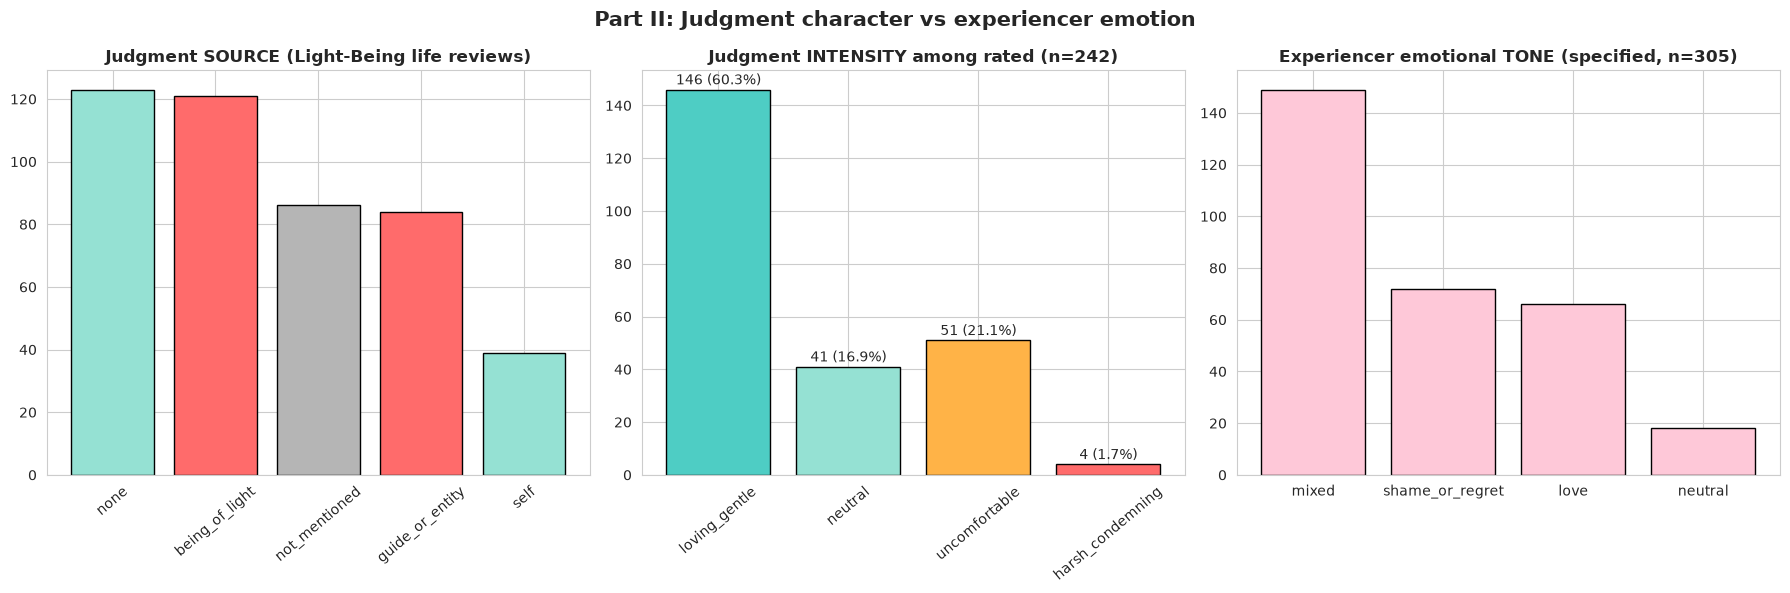

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
ax = axes[0]
src = review["judgment_source"].value_counts()
ax.bar(src.index, src.values, color=["#95E1D3" if s in ("none", "self") else "#B5B5B5" if s == "not_mentioned" else "#FF6B6B" for s in src.index], edgecolor="black")
ax.set_title("Judgment SOURCE (Light-Being life reviews)", fontweight="bold"); ax.tick_params(axis="x", rotation=40)
ax = axes[1]
order = ["loving_gentle", "neutral", "uncomfortable", "harsh_condemning"]
vals = [int((rated.judgment_intensity == o).sum()) for o in order]
ax.bar(order, vals, color=["#4ECDC4", "#95E1D3", "#FFB347", "#FF6B6B"], edgecolor="black")
for i, v in enumerate(vals):
    ax.text(i, v + 2, f"{v} ({100*v/len(rated):.1f}%)", ha="center")
ax.set_title(f"Judgment INTENSITY among rated (n={len(rated)})", fontweight="bold"); ax.tick_params(axis="x", rotation=40)
ax = axes[2]
spec = specified["life_review_emotional_tone"].value_counts()
ax.bar(spec.index, spec.values, color="#FEC8D8", edgecolor="black")
ax.set_title(f"Experiencer emotional TONE (specified, n={len(specified)})", fontweight="bold")
plt.suptitle("Part II: Judgment character vs experiencer emotion", fontsize=15, fontweight="bold")
plt.tight_layout(); plt.savefig(OUTPUT_DIR / "01_part2_love_vs_judgment.png", dpi=150, bbox_inches="tight"); plt.show()

---
# PART III: The Communication of the Being

Rates are **per experiencer** (an NDE can report several modes). Communication and guidance are coded per NDE, not per being, so in mixed encounters they cannot be attributed to the Being alone. Comparisons are reported crude and adjusted for narrative length.

In [13]:
rows = []
for kind, column, values in [
    ("mode", "communication_modes", ["telepathic", "nonverbal", "normal_speech", "not_specified", "no_communication"]),
    ("guidance type", "guidance_types", ["teaching", "life_guidance", "informational", "comfort", "directional", "other"]),
]:
    for v in values:
        cmp[v] = nd.has(cmp, column, v).astype(int)
        t = pd.crosstab(cmp["light_being"], cmp[v])
        chi2, p, _, _ = chi2_contingency(t)
        a = nd.adjusted_odds_ratio(cmp, v, "light_being")
        r = cmp.groupby("light_being")[v].mean()
        rows.append({"kind": kind, "value": v, "Light Being %": round(100*r[1], 1), "Other only %": round(100*r[0], 1),
                     "ratio": round(r[1]/r[0], 2) if r[0] else np.nan, "χ²": round(chi2, 1), "p": p,
                     "adj OR": round(a["adj_or"], 2), "adj 95% CI": f"{a['adj_ci'][0]:.2f}–{a['adj_ci'][1]:.2f}", "adj p": a["adj_p"]})
comm_table = pd.DataFrame(rows)
comm_table["p_holm"] = multipletests(comm_table["p"], method="holm")[1]
print(comm_table.to_string(index=False, float_format=lambda x: f"{x:.3g}"))

mentions = Counter(m for ms in lb["communication_modes"] for m in ms)
total = sum(mentions.values())
print("\nFor reference, share of MENTIONS (the metric used previously):",
      {k: round(100*v/total, 1) for k, v in mentions.most_common()})

         kind            value  Light Being %  Other only %  ratio   χ²        p  adj OR adj 95% CI    adj p   p_holm
         mode       telepathic           48.2          34.2   1.41 75.6 3.55e-18    1.53  1.33–1.76 1.48e-09 3.55e-17
         mode        nonverbal           40.2            28   1.44 62.2 3.14e-15     1.5  1.30–1.73  2.1e-08 2.83e-14
         mode    normal_speech           30.5          40.1   0.76   38 7.23e-10    0.69  0.60–0.79 6.73e-08 5.78e-09
         mode    not_specified             15          13.2   1.14  2.4    0.118    1.26  1.05–1.52   0.0137    0.355
         mode no_communication            4.6           5.6   0.83  1.6    0.206    0.84  0.63–1.13    0.259    0.411
guidance type         teaching           25.3          12.6   2.01   98  4.2e-23    1.96  1.64–2.35 1.92e-13 4.62e-22
guidance type    life_guidance           36.3          27.9    1.3 30.5 3.34e-08    1.28  1.11–1.48 0.000659 2.34e-07
guidance type    informational           37.8          3

**Findings (statistically supported).**
- **Teaching** guidance is reported in ~25% of Light-Being encounters vs ~13% of other-being-only encounters — about **2×**, and the difference survives adjustment for narrative length (adjusted OR ≈ 2.0). This is the correct basis for any "nearly double" statement.
- **Telepathic** communication is reported by ~48% of Light-Being experiencers (the previously quoted 34.8% was a share of mentions), vs ~34% with other beings only (adjusted OR ≈ 1.5). Normal speech is *less* common with the Light Being.
- Directional guidance and comfort do not differ after adjustment.

---
# PART IV: The Identification of the Being

In [14]:
def first_listed(ids):
    for b in ids:
        if b in nd.LIGHT_BEING_IDS:
            return b

lb["first_listed_id"] = lb["being_identifications"].apply(first_listed)
lb["unknown_only"] = lb["being_identifications"].apply(lambda ids: "unknown_presence" in ids and not set(ids) & set(nd.RELIGIOUS_FIGURE_IDS))
lb["named_figure"] = ~lb["unknown_only"]

print("1. IDENTIFICATION DISTRIBUTION (n = %d)" % len(lb))
print("   Order-independent: unknown presence ONLY (no named figure):", nd.fmt_pct(int(lb.unknown_only.sum()), len(lb)))
print("   First-listed identification (depends on the order the extractor listed items):")
for k, v in lb["first_listed_id"].value_counts().items():
    print(f"     {k:28s} {nd.fmt_pct(int(v), len(lb))}")
for k in ["god", "jesus", "religious_figure_specified", "buddha"]:
    print(f"   any mention of {k:26s} {int(nd.has(lb, 'being_identifications', k).sum())}")

1. IDENTIFICATION DISTRIBUTION (n = 1881)
   Order-independent: unknown presence ONLY (no named figure): 951/1881 = 50.6% [95% CI 48.3–52.8]
   First-listed identification (depends on the order the extractor listed items):
     unknown_presence             976/1881 = 51.9% [95% CI 49.6–54.1]
     god                          423/1881 = 22.5% [95% CI 20.7–24.4]
     jesus                        355/1881 = 18.9% [95% CI 17.2–20.7]
     religious_figure_specified   122/1881 = 6.5% [95% CI 5.5–7.7]
     buddha                       5/1881 = 0.3% [95% CI 0.1–0.6]
   any mention of god                        499
   any mention of jesus                      399
   any mention of religious_figure_specified 158
   any mention of buddha                     7


About half of Light-Being encounters are identified **only** as an unknown presence (50.6% order-independent; 51.9% previously, which counted cases where `unknown_presence` was merely listed first alongside a named figure).

### Does religious background predict the name used?

In [15]:
full = pd.crosstab(lb["religious_background"], lb["first_listed_id"])
chi2, p, dof, expected = chi2_contingency(full)
contrib = (full - expected) ** 2 / expected
print(f"Full table (9 backgrounds × 5 labels): χ² = {chi2:.2f}, df = {dof}, p = {p:.2g}")
print("  " + nd.expected_count_report(full))
print(f"  Contribution of the 'buddha' column: {contrib['buddha'].sum():.1f} ({100*contrib['buddha'].sum()/chi2:.0f}% of χ²)")
print("  Largest cell contributions:")
print(contrib.stack().sort_values(ascending=False).head(5).round(1).to_string())

rng = np.random.default_rng(2026)
rb, ids = lb["religious_background"].values, lb["first_listed_id"].values
perm = [chi2_contingency(pd.crosstab(rb, rng.permutation(ids)))[0] for _ in range(2000)]
print(f"  Permutation p (2,000 shuffles): {(np.sum(np.array(perm) >= chi2) + 1) / 2001:.4f}")

def collapse(r):
    return {"christian": "christian", "atheist_agnostic": "non-religious", "spiritual_not_religious": "non-religious",
            "not_mentioned": "not_mentioned"}.get(r, "other religion")
lb["religion_group"] = lb["religious_background"].apply(collapse)
lb["label"] = lb["first_listed_id"].replace({"buddha": "religious_figure_specified"})
known = lb[lb["religion_group"] != "not_mentioned"]
col = pd.crosstab(known["religion_group"], known["label"])
chi2c, pc, dofc, _ = chi2_contingency(col)
print(f"\nCollapsed table, religion known (n = {len(known)}): χ² = {chi2c:.2f}, df = {dofc}, p = {pc:.3f}, Cramér's V = {nd.cramers_v(col):.3f}")
print("  " + nd.expected_count_report(col))
print((100 * col.div(col.sum(axis=1), axis=0)).round(1).to_string())

Full table (9 backgrounds × 5 labels): χ² = 365.14, df = 32, p = 3.6e-58
  min expected = 0.01; cells with expected < 5: 69%
  Contribution of the 'buddha' column: 298.6 (82% of χ²)
  Largest cell contributions:
religious_background  first_listed_id           
buddhist              buddha                        297.0
hindu                 religious_figure_specified     16.8
christian             jesus                          10.6
                      unknown_presence                5.8
                      religious_figure_specified      4.4


  Permutation p (2,000 shuffles): 0.0005

Collapsed table, religion known (n = 590): χ² = 15.04, df = 6, p = 0.020, Cramér's V = 0.113
  min expected = 2.85; cells with expected < 5: 17%
label            god  jesus  religious_figure_specified  unknown_presence
religion_group                                                           
christian       21.8   25.1                         8.8              44.2
non-religious   10.0   10.0                        13.3              66.7
other religion  19.6    9.8                        13.7              56.9


**Correction.** The previously reported χ² = 365.14 is not interpretable: 69% of its cells had expected counts below 5, and ~82% of the statistic came from two Buddhists who named the Buddha (expected ≈ 0.01). A permutation test confirms that *some* association exists, and on a table that satisfies the test's assumptions the association is **weak** (χ²(6) ≈ 15, p ≈ 0.02, Cramér's V ≈ 0.11). Christians name God/Jesus more and "unknown presence" less (44%) than non-religious experiencers (67%, n = 30).

*Interpretation (framework-consistent, not proven):* weak cultural shaping of vocabulary with a majority of "unknown presence" identifications in every group is compatible with "constant state, variable form", but a weak association is also what a modest cultural-priming effect would produce.

### Do experiencers who use different names report different properties?

In [16]:
def property_table(a, b, label_a, label_b):
    """Compare binary properties between two groups with proper denominators, Fisher tests and Holm correction."""
    defs = {
        "guidance received": (lambda d: d.guidance_received == "yes", None),
        "teaching guidance": (lambda d: nd.has(d, "guidance_types", "teaching"), None),
        "telepathic communication": (lambda d: nd.has(d, "communication_modes", "telepathic"), None),
        "life review": (lambda d: d.life_review, None),
        "loving judgment | rated": (lambda d: d.judgment_intensity == "loving_gentle",
                                    lambda d: d.judgment_intensity.isin(["loving_gentle", "neutral", "uncomfortable", "harsh_condemning"])),
        "love tone | tone specified": (lambda d: d.life_review_emotional_tone == "love",
                                       lambda d: d.life_review & (d.life_review_emotional_tone != "not_specified")),
        "pleasant valence | stated": (lambda d: d.overall_valence.isin(["pleasant", "incredibly_pleasant"]),
                                      lambda d: d.overall_valence != "not_mentioned"),
        "light_encounter = being_of_light": (lambda d: d.light_encounter == "being_of_light", None),
        "unity experience": (lambda d: nd.isin(d, "unity_experience", nd.YES), None),
        "sense of belonging": (lambda d: d.sense_of_belonging.isin(["explicit", "implied"]), None),
        "mission commissioned": (lambda d: nd.isin(d, "mission_commissioned", nd.YES), None),
    }
    rows = []
    for name, (f, mask) in defs.items():
        xa = f(a)[mask(a)] if mask else f(a)
        xb = f(b)[mask(b)] if mask else f(b)
        ka, na_, kb, nb_ = int(xa.sum()), len(xa), int(xb.sum()), len(xb)
        p = fisher_exact([[ka, na_ - ka], [kb, nb_ - kb]])[1]
        d = ka / na_ - kb / nb_
        se = np.sqrt(ka/na_*(1-ka/na_)/na_ + kb/nb_*(1-kb/nb_)/nb_)
        rows.append({"property": name, label_a: f"{ka}/{na_} ({100*ka/na_:.1f}%)", label_b: f"{kb}/{nb_} ({100*kb/nb_:.1f}%)",
                     "diff (pp)": round(100*d, 1), "95% CI": f"{100*(d-1.96*se):.1f} to {100*(d+1.96*se):.1f}", "p": p})
    t = pd.DataFrame(rows)
    t["p_holm"] = multipletests(t["p"], method="holm")[1]
    return t

named = lb[lb["named_figure"]]
unknown = lb[lb["unknown_only"]]
print(f"ALL LIGHT-BEING ENCOUNTERS: named figure (n={len(named)}) vs unknown presence only (n={len(unknown)})")
print(property_table(named, unknown, "named", "unknown only").to_string(index=False, float_format=lambda x: f"{x:.3g}"))

ALL LIGHT-BEING ENCOUNTERS: named figure (n=930) vs unknown presence only (n=951)


                        property           named    unknown only  diff (pp)       95% CI        p   p_holm
               guidance received 758/930 (81.5%) 779/951 (81.9%)       -0.4  -3.9 to 3.1    0.858        1
               teaching guidance 275/930 (29.6%) 200/951 (21.0%)        8.5  4.6 to 12.5 2.14e-05 0.000214
        telepathic communication 462/930 (49.7%) 445/951 (46.8%)        2.9  -1.6 to 7.4    0.213        1
                     life review 244/930 (26.2%) 209/951 (22.0%)        4.3   0.4 to 8.1   0.0312    0.218
         loving judgment | rated  93/150 (62.0%)  59/108 (54.6%)        7.4 -4.8 to 19.6     0.25        1
      love tone | tone specified  35/176 (19.9%)  31/129 (24.0%)       -4.1 -13.6 to 5.3    0.401        1
       pleasant valence | stated 458/891 (51.4%) 411/925 (44.4%)          7  2.4 to 11.6  0.00308   0.0247
light_encounter = being_of_light 418/930 (44.9%) 181/951 (19.0%)       25.9 21.9 to 30.0 5.48e-34 6.03e-33
                unity experience 325/

**Finding (mixed).** Guidance, telepathy, belonging, judgment character and emotional tone do not differ between named and unnamed encounters — consistent with a constant *functional* profile. However, named-figure encounters are far more often coded as a visual Being of Light (+26 pp), and report more teaching and more mission commissioning. The Christian-only comparison (Jesus-only vs Unknown-only) is in notebook 04, Part V.

In [17]:
print("NON-RELIGIOUS EXPERIENCERS (atheist/agnostic or SBNR background) — how they name the Being")
nonrel = lb[lb["religious_background"].isin(["atheist_agnostic", "spiritual_not_religious"])]
for k, v in nonrel["first_listed_id"].value_counts().items():
    print(f"  {k:28s} {nd.fmt_pct(int(v), len(nonrel))}")
print(f"  Using religious vocabulary (God/Jesus/named figure): {nd.fmt_pct(int(nonrel.named_figure.sum()), len(nonrel))}")

chr_lb = lb[lb["religious_background"] == "christian"]
print(f"\nCHRISTIAN BACKGROUND (n = {len(chr_lb)}):")
print(f"  Unknown presence only: {nd.fmt_pct(int(chr_lb.unknown_only.sum()), len(chr_lb))}")
print(f"  Any mention of Jesus:  {nd.fmt_pct(int(nd.has(chr_lb, 'being_identifications', 'jesus').sum()), len(chr_lb))}")

NON-RELIGIOUS EXPERIENCERS (atheist/agnostic or SBNR background) — how they name the Being
  unknown_presence             20/30 = 66.7% [95% CI 48.8–80.8]
  religious_figure_specified   4/30 = 13.3% [95% CI 5.3–29.7]
  jesus                        3/30 = 10.0% [95% CI 3.5–25.6]
  god                          3/30 = 10.0% [95% CI 3.5–25.6]
  Using religious vocabulary (God/Jesus/named figure): 12/30 = 40.0% [95% CI 24.6–57.7]

CHRISTIAN BACKGROUND (n = 509):
  Unknown presence only: 217/509 = 42.6% [95% CI 38.4–47.0]
  Any mention of Jesus:  143/509 = 28.1% [95% CI 24.4–32.2]


---
# PART V: The Transformation by the Being

Before/after levels are compared only where **both** were stated. This is a strong selection: experiencers tend to mention their earlier fear or spirituality precisely when it changed, so the percentages describe that subset and overstate the population-wide rate of change. Light-Being encounters are compared with other-being-only encounters to see whether effects are specific to the Being.

In [18]:
def pre_post(frame, before, after, scale, label):
    m = frame[before].isin(scale) & frame[after].isin(scale)
    x, y = frame.loc[m, before].map(scale), frame.loc[m, after].map(scale)
    n = int(m.sum())
    res = wilcoxon(x, y) if (x != y).any() else None
    print(f"  {label}: n = {n}; mean {x.mean():.2f} → {y.mean():.2f}; "
          f"decreased {int((y<x).sum())} ({100*(y<x).mean():.1f}%), increased {int((y>x).sum())} ({100*(y>x).mean():.1f}%), "
          f"unchanged {int((y==x).sum())} ({100*(y==x).mean():.1f}%)" + (f"; Wilcoxon p = {res.pvalue:.2g}" if res else ""))
    return (x - y) if "fear" in before else (y - x)

print("1. DEATH FEAR (0 = none … 4 = severe)")
fear_lb = pre_post(lb, "death_fear_before", "death_fear_after", nd.FEAR_SCALE, "Light Being")
fear_oo = pre_post(other_only, "death_fear_before", "death_fear_after", nd.FEAR_SCALE, "Other beings only")
fear_all = pre_post(df, "death_fear_before", "death_fear_after", nd.FEAR_SCALE, "All NDEs")
u = mannwhitneyu(fear_lb, fear_oo)
print(f"  Reduction, Light Being vs other only: Mann-Whitney U = {u.statistic:.0f}, p = {u.pvalue:.2f}")

print("\n2. SPIRITUALITY (0 = none … 4 = central)")
sp_lb = pre_post(lb, "spirituality_before", "spirituality_after", nd.SPIRITUALITY_SCALE, "Light Being")
sp_oo = pre_post(other_only, "spirituality_before", "spirituality_after", nd.SPIRITUALITY_SCALE, "Other beings only")
print(f"  Increase, Light Being vs other only: mean +{sp_lb.mean():.2f} vs +{sp_oo.mean():.2f}; Mann-Whitney p = {mannwhitneyu(sp_lb, sp_oo).pvalue:.3g}")
print(f"  Reaching 'central' after: Light Being {100*(lb.loc[sp_lb.index, 'spirituality_after']=='central').mean():.1f}% vs other only {100*(other_only.loc[sp_oo.index, 'spirituality_after']=='central').mean():.1f}%")

print("\n3. RELIGIOSITY (0 = none … 4 = devout)")
pre_post(lb, "religiosity_before", "religiosity_after", nd.RELIGIOSITY_SCALE, "Light Being")
pre_post(df, "religiosity_before", "religiosity_after", nd.RELIGIOSITY_SCALE, "All NDEs")

print("\n4. VALUE SHIFT (Light Being; 'not_mentioned' excluded)")
vs = lb.loc[lb["value_shift"] != "not_mentioned", "value_shift"]
for k, v in vs.value_counts().items():
    print(f"  {k:8s} {nd.fmt_pct(int(v), len(vs))}")

1. DEATH FEAR (0 = none … 4 = severe)
  Light Being: n = 117; mean 2.52 → 0.31; decreased 103 (88.0%), increased 1 (0.9%), unchanged 13 (11.1%); Wilcoxon p = 1e-18
  Other beings only: n = 84; mean 2.51 → 0.26; decreased 74 (88.1%), increased 3 (3.6%), unchanged 7 (8.3%); Wilcoxon p = 8.9e-14
  All NDEs: n = 327; mean 2.43 → 0.31; decreased 277 (84.7%), increased 13 (4.0%), unchanged 37 (11.3%); Wilcoxon p = 4.9e-46
  Reduction, Light Being vs other only: Mann-Whitney U = 4743, p = 0.65

2. SPIRITUALITY (0 = none … 4 = central)
  Light Being: n = 305; mean 1.66 → 3.23; decreased 3 (1.0%), increased 272 (89.2%), unchanged 30 (9.8%); Wilcoxon p = 6.6e-48
  Other beings only: n = 175; mean 1.57 → 2.90; decreased 2 (1.1%), increased 150 (85.7%), unchanged 23 (13.1%); Wilcoxon p = 2.6e-27
  Increase, Light Being vs other only: mean +1.58 vs +1.33; Mann-Whitney p = 0.00334
  Reaching 'central' after: Light Being 37.7% vs other only 14.9%

3. RELIGIOSITY (0 = none … 4 = devout)
  Light Being:

**Findings.**
- *Statistically supported:* where both levels are stated, death fear falls in ~88% of Light-Being experiencers and rises in ~1% (1 case of 117; the earlier "0.0% increased" came from a broken scale). Spirituality rises in ~89% (n = 305).
- *Correction:* the **death-fear** reduction is **not specific to the Being of Light** — other-being-only experiencers show the same reduction (p ≈ 0.65).
- *Statistically supported (Being-specific):* the *proportion* reporting increased spirituality is similar (89% vs 86%), but the **size** of the increase is larger after Light-Being encounters (mean +1.58 vs +1.33 levels, p ≈ 0.003; the difference persists after adjusting for narrative length), and far more Light-Being experiencers end at the top level, "central" (≈38% vs ≈15%).
- Religiosity (institutional practice) shows **no net change**: increases and decreases are equally common.
- All three measures are subject to the reporting-selection caveat above.

---
# SUPPLEMENTARY: Can religious background predict the name used?

The previous version trained a random forest on religion + gender + age (missing ages filled with 30) for the 183 cases with a reported age, and found 37.8% test accuracy (n = 37) vs a 45.9% baseline. Below-baseline accuracy is the signature of a small sample overfit to noise features, not evidence that religion carries *no* information. The test is repeated properly: religion only, all cases with known religion, 5-fold stratified cross-validation, scored by accuracy and log-loss (which rewards calibrated probabilities).

In [19]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier

known = lb[lb["religious_background"] != "not_mentioned"]
X = pd.get_dummies(known["religious_background"]).astype(float)
y = known["first_listed_id"].replace({"buddha": "religious_figure_specified"})
cv = StratifiedKFold(5, shuffle=True, random_state=0)
for name, model in [("prior (no information)", DummyClassifier(strategy="prior")),
                    ("logistic regression on religion", LogisticRegression(max_iter=1000))]:
    r = cross_validate(model, X, y, cv=cv, scoring=["accuracy", "neg_log_loss"])
    print(f"{name:34s} n={len(known)}  accuracy={r['test_accuracy'].mean():.3f}  log-loss={-r['test_neg_log_loss'].mean():.4f}")
yb = (y == "unknown_presence").astype(int)
r = cross_validate(LogisticRegression(max_iter=1000), X, yb, cv=cv, scoring=["roc_auc"])
print(f"Unknown vs named, AUC from religion alone: {r['test_roc_auc'].mean():.3f}")

prior (no information)             n=590  accuracy=0.464  log-loss=1.2459


logistic regression on religion    n=590  accuracy=0.463  log-loss=1.2379


Unknown vs named, AUC from religion alone: 0.527


**Finding:** religion improves prediction only marginally over the no-information baseline (log-loss 1.238 vs 1.246; AUC ≈ 0.53). Religious background is **weakly** informative about the label — consistent with the small Cramér's V above. "Background cannot predict identification" is a fair summary; "the model performs below baseline" is not a valid argument for it.

---
# SUPPLEMENTARY: Demographics of Light-Being encounters

In [20]:
print("Gender:", lb["gender"].value_counts().to_dict())
ages = lb["age_at_nde"].dropna()
print(f"Age at NDE reported for {len(ages)} ({100*len(ages)/len(lb):.1f}%): mean {ages.mean():.1f}, median {ages.median():.0f}, range {ages.min():.0f}–{ages.max():.0f}")
print("Religious background:", lb["religious_background"].value_counts().to_dict())
print(f"Religious background not mentioned: {100*(lb.religious_background=='not_mentioned').mean():.1f}%")

Gender: {'female': 838, 'not_mentioned': 553, 'male': 489, 'non_binary': 1}
Age at NDE reported for 483 (25.7%): mean 18.8, median 15, range 0–78
Religious background: {'not_mentioned': 1291, 'christian': 509, 'other': 28, 'atheist_agnostic': 24, 'jewish': 11, 'spiritual_not_religious': 6, 'buddhist': 5, 'muslim': 4, 'hindu': 3}
Religious background not mentioned: 68.6%


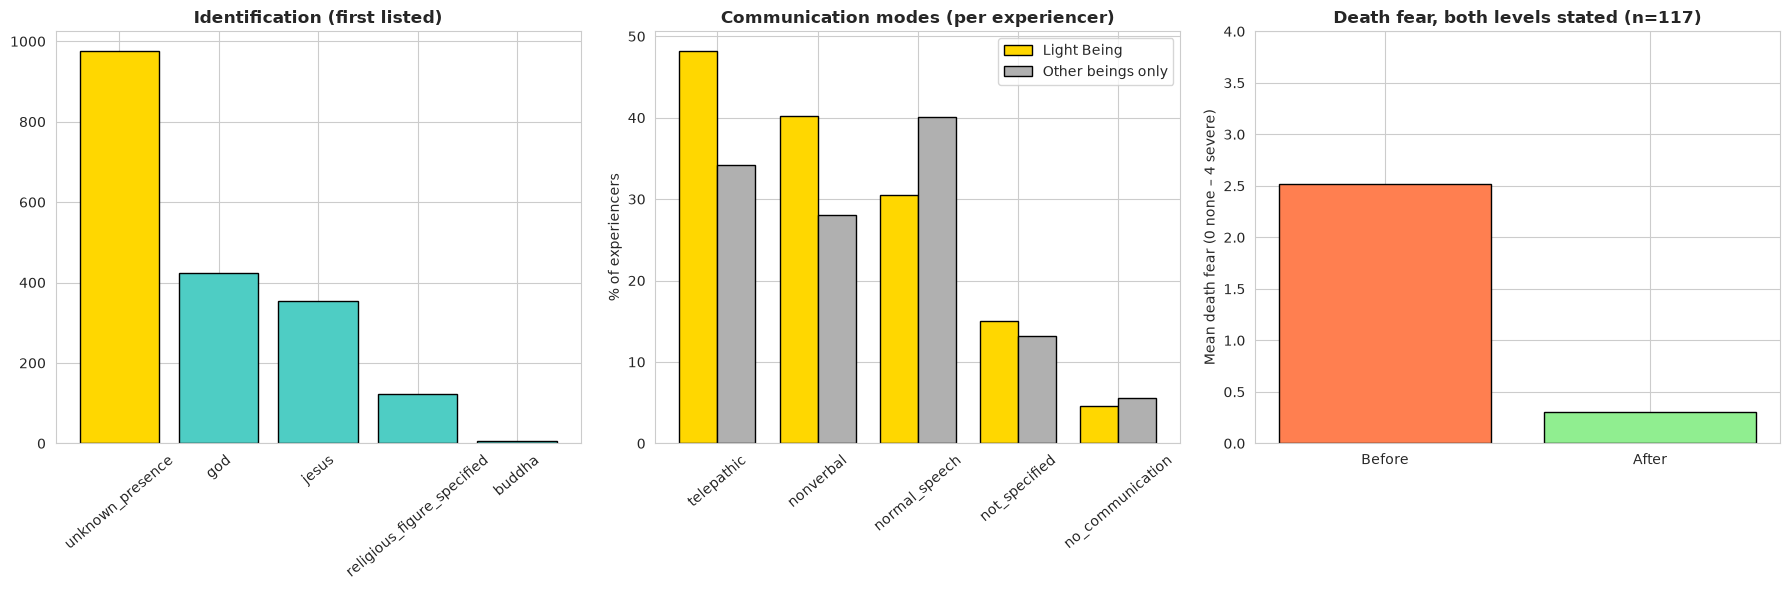

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
ax = axes[0]
dist = lb["first_listed_id"].value_counts()
ax.bar(dist.index, dist.values, color=["#FFD700" if k == "unknown_presence" else "#4ECDC4" for k in dist.index], edgecolor="black")
ax.set_title("Identification (first listed)", fontweight="bold"); ax.tick_params(axis="x", rotation=40)
ax = axes[1]
m = comm_table[comm_table.kind == "mode"]
x = np.arange(len(m)); w = 0.38
ax.bar(x - w/2, m["Light Being %"], w, label="Light Being", color="#FFD700", edgecolor="black")
ax.bar(x + w/2, m["Other only %"], w, label="Other beings only", color="#B0B0B0", edgecolor="black")
ax.set_xticks(x); ax.set_xticklabels(m["value"], rotation=40); ax.set_ylabel("% of experiencers"); ax.legend()
ax.set_title("Communication modes (per experiencer)", fontweight="bold")
ax = axes[2]
fm = lb[lb.death_fear_before.isin(nd.FEAR_SCALE) & lb.death_fear_after.isin(nd.FEAR_SCALE)]
ax.bar(["Before", "After"], [fm.death_fear_before.map(nd.FEAR_SCALE).mean(), fm.death_fear_after.map(nd.FEAR_SCALE).mean()],
       color=["coral", "lightgreen"], edgecolor="black")
ax.set_ylim(0, 4); ax.set_ylabel("Mean death fear (0 none – 4 severe)")
ax.set_title(f"Death fear, both levels stated (n={len(fm)})", fontweight="bold")
plt.tight_layout(); plt.savefig(OUTPUT_DIR / "01_being_of_light_summary.png", dpi=150, bbox_inches="tight"); plt.show()

---
# Conclusion: Being of Light profile (corrected)

| Part | Result | Level of claim |
|---|---|---|
| Presence | 27.9% of NDEs include a divine-figure or unidentified-presence identification; varies by religious background (Christian ≈40%, Muslim ≈9%); no gender or age differences | Statistically supported |
| Construct | Only ~32% of that subset was coded as a visual *being of light*; ~15% report no light | Descriptive caveat |
| Singularity | Not measurable with the schema; 2 of the 8 Hindu/Buddhist cases name several divine figures | **Underdetermined** (previous "hit" withdrawn) |
| Judgment character | Harsh evaluation ≈2% of rated reviews; loving ≈60% (≈75% when the Being evaluates); loving:harsh ≈36:1 (95% CI 14–136); loving:critical ≈2.7:1 | Statistically supported (with corrected magnitude) |
| External evaluation | ≈56% of classifiable reviews involve an external evaluator (not "54.7% no external judgment") | Correction |
| Experiencer emotion | Mixed is modal; love ≈ shame/regret | Statistically supported |
| Communication | Telepathy 48% vs 34% (other beings); teaching ≈2× (25% vs 13%); both survive length adjustment | Statistically supported |
| Guidance overall | 81.7% vs 74.9% (ratio 1.09×) | Statistically supported, modest |
| Identification | ~51% unknown presence only; religion → label association is weak (V ≈ 0.11); χ² = 365 was a sparse-cell artifact | Statistically supported (weak association) |
| Named vs unnamed | Same guidance/telepathy/judgment/tone; differ in visual-being coding, teaching, mission | Mixed |
| Transformation | Fear ↓ in ~88%, ↑ in ~1% (same after other-being encounters); spirituality ↑ in ~89%, with a **larger** increase after Light-Being encounters (+1.58 vs +1.33 levels, p ≈ 0.003); religiosity unchanged | Supported; fear effect not Being-specific, spirituality magnitude is |

**Methodological notes.** (1) All fields are LLM extractions from self-selected online narratives; no human validation of the extraction has been performed. (2) Narrative length confounds most "more of X with Y" comparisons; adjusted estimates are reported. (3) Absence of a mention is not absence of the experience; denominators are stated for every percentage.

---
**Notebook**: `01_being_of_light_analysis.ipynb` · **Schema Version**: 2026-01-06 · **Audited**: 2026-10-05